# Exploratory Data Analysis - Trentino Airbnb

Only old listings

**Research Question:** What are the significant spatial factors affecting Airbnb prices in Trentino?

**Workflow:**
1. Load and validate data
2. Descriptive statistics
3. Spatial distribution analysis
4. Correlation analysis
5. Visual exploration

---

In [27]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [28]:
# Load dataset
df = pd.read_csv('../datasets/trentino_listings_maps.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total listings: {len(df)}")
df.head()

Dataset shape: (7660, 23)
Total listings: 7660


,id,price,log_price,price_per_person,room_type,accommodates,n_reviews,municipality,cod_istat,dist_ski,...,dist_bus,dist_center,dist_supermarket,dist_restaurant,dist_bar,dist_pharmacy,dist_castle,dist_museum,lat,long
0,37736,93.0,4.532599,23.250000,Entire home/apt,4,128,Novella,22253,5983.256903,...,686.767246,2591.787722,524.004548,553.292304,2104.594325,2536.900966,1050.191549,2616.353812,46.43561,11.10380
1,56292,90.0,4.499810,22.500000,Entire home/apt,4,23,Pinzolo,22143,217.760309,...,82.009647,2707.498230,51.408723,12.317323,92.799034,149.867838,10904.720696,426.200814,46.23199,10.82732
2,249351,72.0,4.276666,9.000000,Private room,8,12,Malé,22110,7734.469456,...,292.436933,1724.222204,211.209375,743.675731,996.357885,1089.186247,2321.903886,822.894852,46.36155,10.91591
3,299464,94.0,4.543295,31.333333,Entire home/apt,3,1,Riva del Garda,22153,14810.813464,...,140.277109,2941.780487,431.125220,364.812817,508.836574,1027.261858,1342.109137,2551.487432,45.90883,10.84660
4,367596,91.0,4.510860,15.166667,Entire home/apt,6,44,Pinzolo,22143,618.724099,...,96.759867,7411.744320,171.667295,244.260865,48.792808,258.493818,13605.301548,1343.910473,46.15799,10.76669


In [29]:
# Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7660 entries, 0 to 7659
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7660 non-null   int64  
 1   price             7660 non-null   float64
 2   log_price         7660 non-null   float64
 3   price_per_person  7660 non-null   float64
 4   room_type         7660 non-null   str    
 5   accommodates      7660 non-null   int64  
 6   n_reviews         7660 non-null   int64  
 7   municipality      7660 non-null   str    
 8   cod_istat         7660 non-null   int64  
 9   dist_ski          7660 non-null   float64
 10  dist_lake         7660 non-null   float64
 11  dist_park         7660 non-null   float64
 12  dist_station      7660 non-null   float64
 13  dist_bus          7660 non-null   float64
 14  dist_center       7660 non-null   float64
 15  dist_supermarket  7660 non-null   float64
 16  dist_restaurant   7660 non-null   float64
 17  dist_b

In [30]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("⚠️ Missing values found:")
    print(missing)
else:
    print("✅ No missing values!")

✅ No missing values!


In [31]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("⚠️ Missing values found:")
    print(missing)
else:
    print("✅ No missing values!")

✅ No missing values!


In [32]:
# Check for extreme outliers in distances (99999 = dummy values)
distance_cols = [col for col in df.columns if col.startswith('dist_')]

print("Distance columns with dummy values (99999):")
for col in distance_cols:
    dummy_count = (df[col] == 99999).sum()
    if dummy_count > 0:
        print(f"  {col}: {dummy_count} listings ({dummy_count/len(df)*100:.1f}%)")

Distance columns with dummy values (99999):


In [33]:
# Price distribution
print("=== PRICE STATISTICS ===")
print(df[['price', 'log_price']].describe())

print(f"\nMedian price: ${df['price'].median():.2f}")
print(f"Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")

=== PRICE STATISTICS ===
             price    log_price
count  7660.000000  7660.000000
mean    146.745170     4.805985
std     131.865006     0.535756
min      10.000000     2.302585
25%      88.000000     4.477337
50%     116.000000     4.753590
75%     154.000000     5.036953
max    1999.000000     7.600402

Median price: $116.00
Price range: $10.00 - $1999.00


In [34]:
# Room type distribution
print("=== ROOM TYPE DISTRIBUTION ===")
room_counts = df['room_type'].value_counts()
print(room_counts)
print(f"\nPercentages:")
print(room_counts / len(df) * 100)

=== ROOM TYPE DISTRIBUTION ===
room_type
Entire home/apt    6691
Private room        944
Hotel room           18
Shared room           7
Name: count, dtype: int64

Percentages:
room_type
Entire home/apt    87.349869
Private room       12.323760
Hotel room          0.234987
Shared room         0.091384
Name: count, dtype: float64


In [35]:
# Accommodates distribution
print("=== ACCOMMODATES STATISTICS ===")
print(df['accommodates'].describe())
print(f"\nMost common capacity: {df['accommodates'].mode()[0]} guests")

=== ACCOMMODATES STATISTICS ===
count    7660.000000
mean        4.475587
std         1.875705
min         1.000000
25%         4.000000
50%         4.000000
75%         6.000000
max        16.000000
Name: accommodates, dtype: float64

Most common capacity: 4 guests


In [36]:
# Top municipalities
print("=== TOP 15 MUNICIPALITIES BY NUMBER OF LISTINGS ===")
top_municipalities = df['municipality'].value_counts().head(15)
print(top_municipalities)

=== TOP 15 MUNICIPALITIES BY NUMBER OF LISTINGS ===
municipality
Riva del Garda                       745
Trento                               468
Arco                                 434
Pinzolo                              364
Ledro                                334
Canazei                              235
Nago-Torbole                         230
San Giovanni di Fassa-Sèn Jan        210
Dimaro Folgarida                     165
Mezzana                              145
Primiero San Martino di Castrozza    140
Campitello di Fassa                  132
Moena                                130
Predazzo                             128
Rovereto                             115
Name: count, dtype: int64


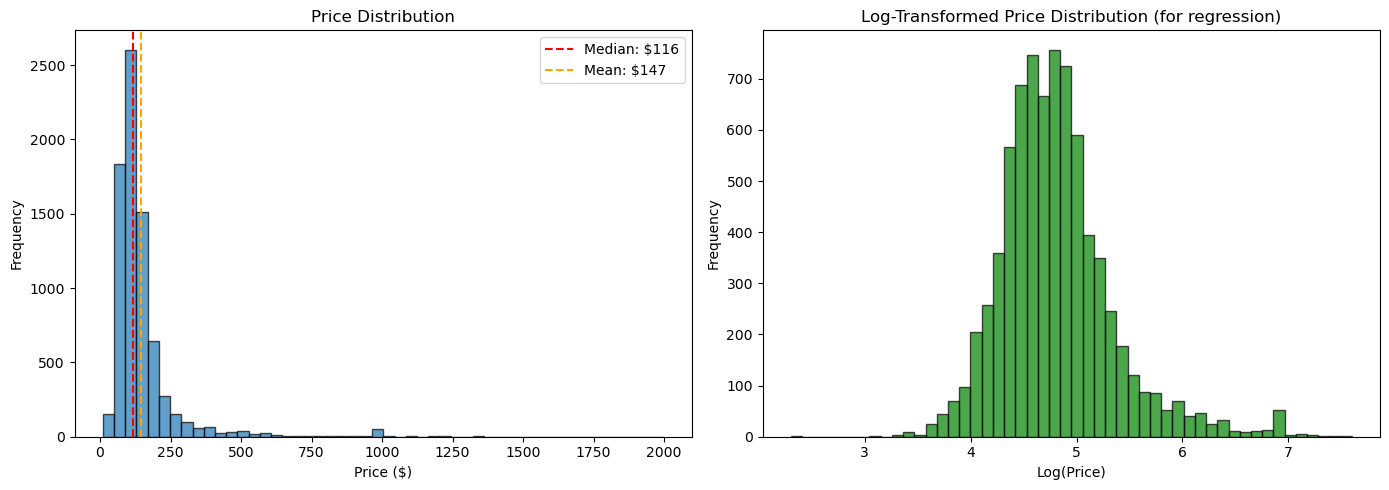

In [37]:
# Price distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of price
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f'Median: ${df["price"].median():.0f}')
axes[0].axvline(df['price'].mean(), color='orange', linestyle='--', label=f'Mean: ${df["price"].mean():.0f}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')
axes[0].legend()

# Log-transformed price
axes[1].hist(df['log_price'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Price Distribution (for regression)')

plt.tight_layout()
plt.show()

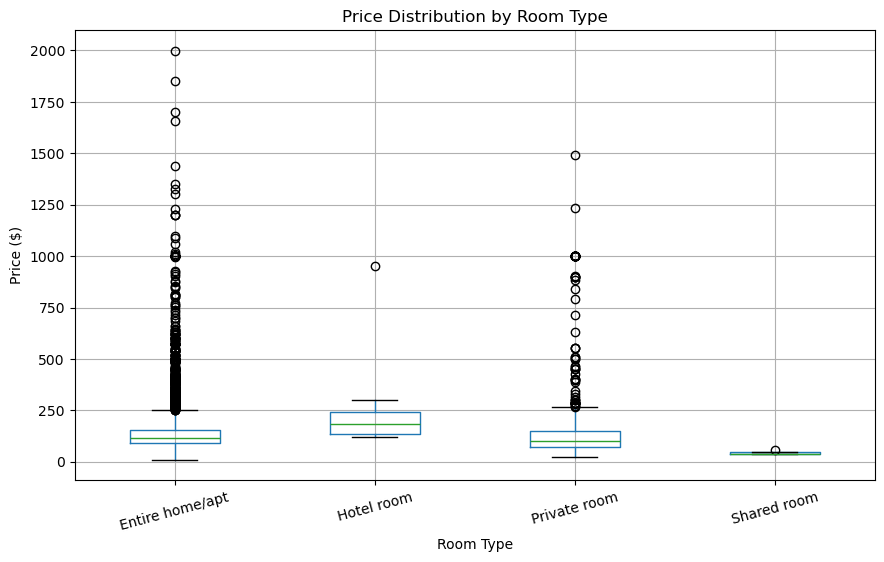


Mean price by room type:
                       mean  median  count
room_type                                 
Entire home/apt  145.810641   118.0   6691
Hotel room       232.000000   184.0     18
Private room     152.510593   103.0    944
Shared room       43.285714    38.0      7


In [38]:
# Price by room type
plt.figure(figsize=(10, 6))
df.boxplot(column='price', by='room_type', ax=plt.gca())
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.title('Price Distribution by Room Type')
plt.suptitle('')  # Remove default title
plt.xticks(rotation=15)
plt.show()

# Summary statistics by room type
print("\nMean price by room type:")
print(df.groupby('room_type')['price'].agg(['mean', 'median', 'count']))

In [39]:
# Convert to GeoDataFrame for mapping
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.long, df.lat),
    crs='EPSG:4326'
)

print(f"GeoDataFrame created with {len(gdf)} points")

GeoDataFrame created with 7660 points


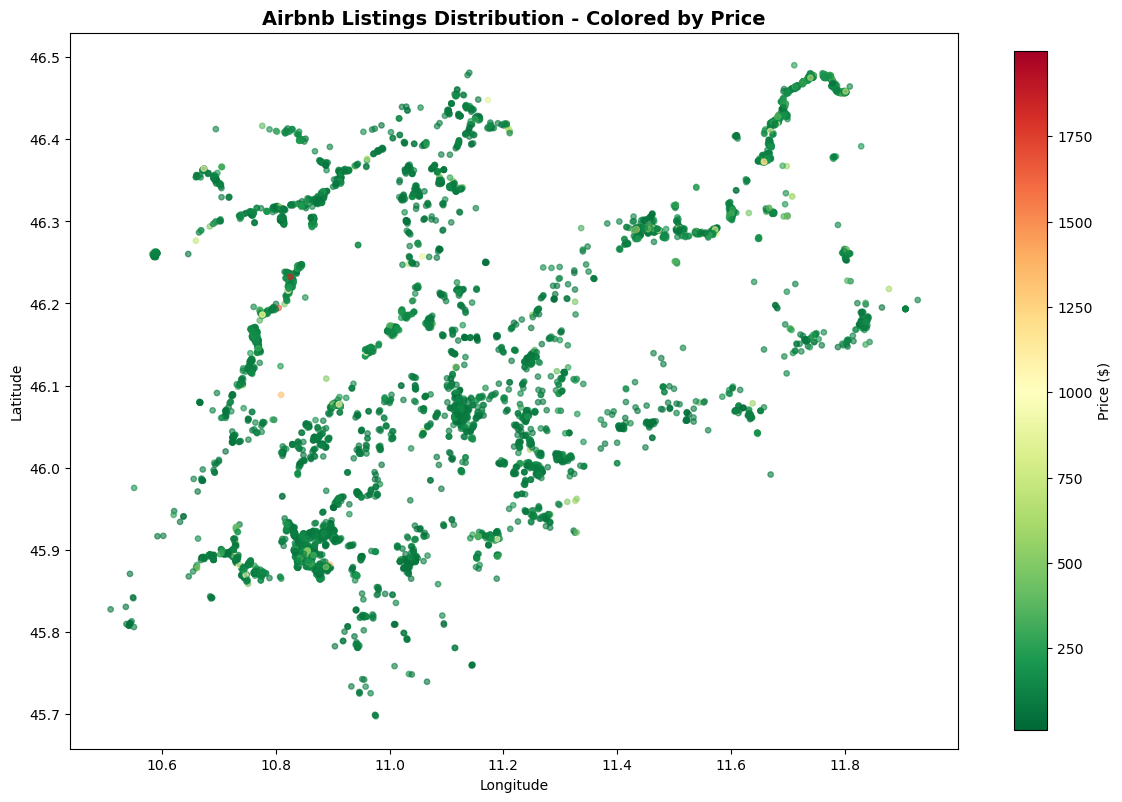

In [40]:
# Map of listings colored by price
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    column='price',
    cmap='RdYlGn_r',  # Red = expensive, Green = cheap
    legend=True,
    markersize=15,
    alpha=0.6,
    ax=ax,
    legend_kwds={'label': 'Price ($)', 'shrink': 0.7}
)

ax.set_title('Airbnb Listings Distribution - Colored by Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

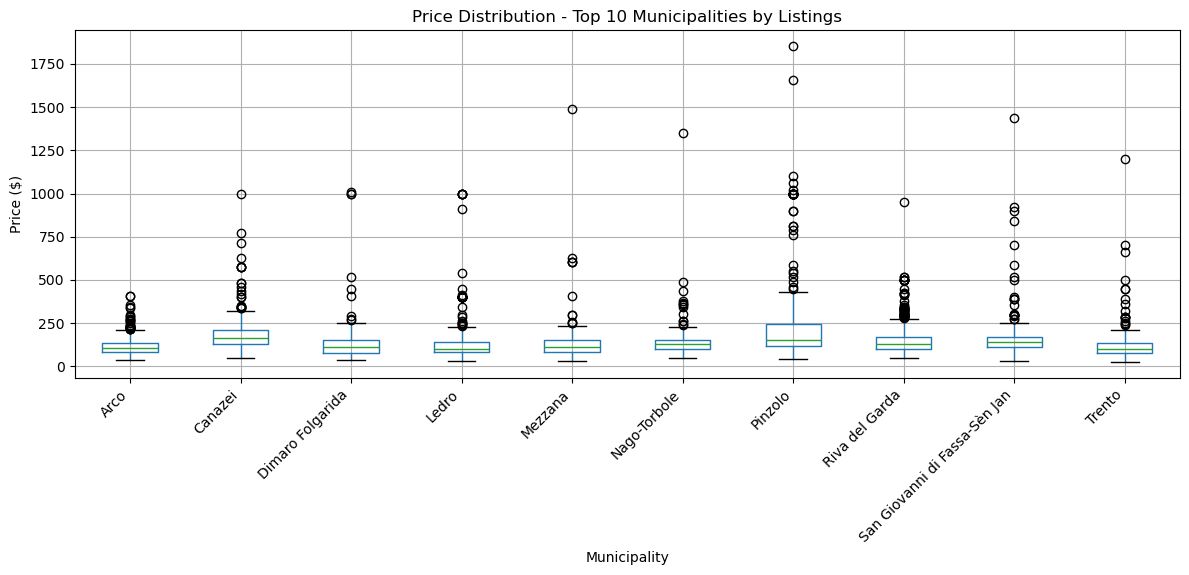

In [41]:
# Price by municipality (top 10)
top_10_municipalities = df['municipality'].value_counts().head(10).index
df_top10 = df[df['municipality'].isin(top_10_municipalities)]

plt.figure(figsize=(12, 6))
df_top10.boxplot(column='price', by='municipality', ax=plt.gca())
plt.xlabel('Municipality')
plt.ylabel('Price ($)')
plt.title('Price Distribution - Top 10 Municipalities by Listings')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [42]:
# Filter out dummy values (99999) for analysis
df_clean = df.copy()
for col in distance_cols:
    df_clean.loc[df_clean[col] == 99999, col] = np.nan

# Summary statistics for distances (in meters)
print("=== DISTANCE STATISTICS (meters) ===")
distance_stats = df_clean[distance_cols].describe().T
distance_stats['mean_km'] = distance_stats['mean'] / 1000
distance_stats['median_km'] = distance_stats['50%'] / 1000
print(distance_stats[['mean_km', 'median_km', 'min', 'max']])

=== DISTANCE STATISTICS (meters) ===
                   mean_km  median_km        min           max
dist_ski          5.909479   4.421361   0.397194  22667.047204
dist_lake         0.730188   0.458379   0.000000   4805.884925
dist_park         1.275681   0.566153   0.000000  12195.768913
dist_station      8.038656   6.108845  42.375993  31060.718221
dist_bus          0.266766   0.171567   0.907233   7206.352800
dist_center       2.929597   2.511112  35.836316  13588.363714
dist_supermarket  0.636457   0.358302   0.000000   8404.598927
dist_restaurant   0.390332   0.226850   0.000000   6598.024687
dist_bar          0.600424   0.306288   0.000000   7672.597770
dist_pharmacy     1.141615   0.576011   2.781601  10540.444294
dist_castle       5.852907   3.810882   0.000000  22950.541474
dist_museum       2.435113   1.914871   0.050095  12907.893914


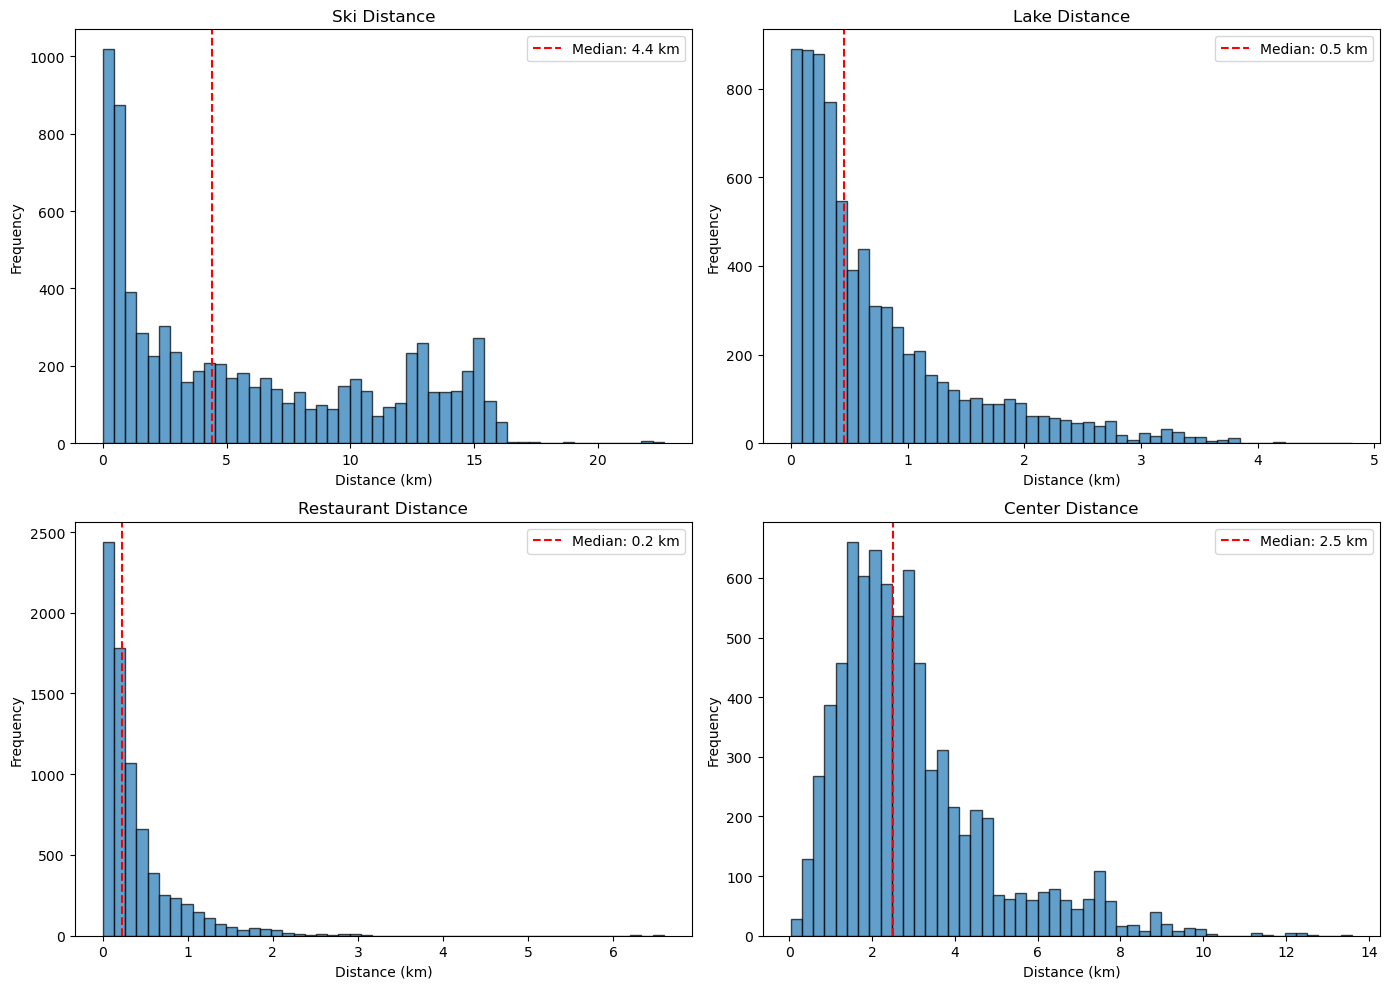

In [43]:
# Distribution of key distances
key_distances = ['dist_ski', 'dist_lake', 'dist_restaurant', 'dist_center']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_distances):
    data = df_clean[col].dropna() / 1000  # Convert to km
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7)
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.1f} km')
    axes[i].set_xlabel('Distance (km)')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{col.replace("dist_", "").replace("_", " ").title()} Distance')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [44]:
# Select numeric variables for correlation
numeric_cols = ['price', 'accommodates', 'n_reviews'] + distance_cols
corr_data = df_clean[numeric_cols]

# Correlation with price
price_corr = corr_data.corr()['price'].drop('price').sort_values(ascending=False)
print("=== CORRELATION WITH PRICE ===")
print(price_corr)

=== CORRELATION WITH PRICE ===
accommodates        0.250607
dist_castle         0.183564
dist_station        0.109164
dist_park           0.042092
dist_supermarket    0.041538
dist_lake           0.028508
dist_bus            0.027332
dist_pharmacy       0.016558
dist_center         0.000167
dist_restaurant    -0.005442
dist_bar           -0.011903
dist_museum        -0.016042
dist_ski           -0.126129
n_reviews          -0.127649
Name: price, dtype: float64


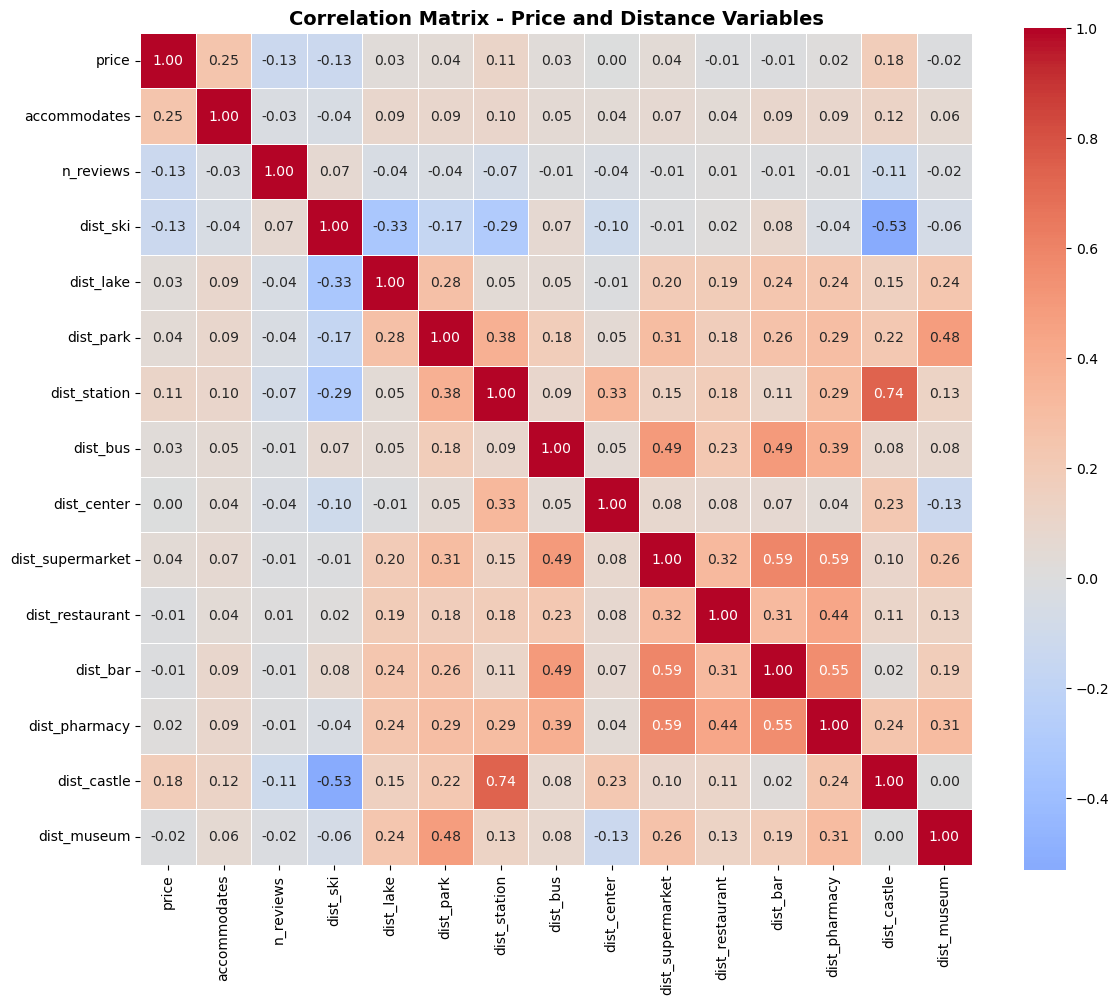

In [45]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = corr_data.corr()
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix - Price and Distance Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

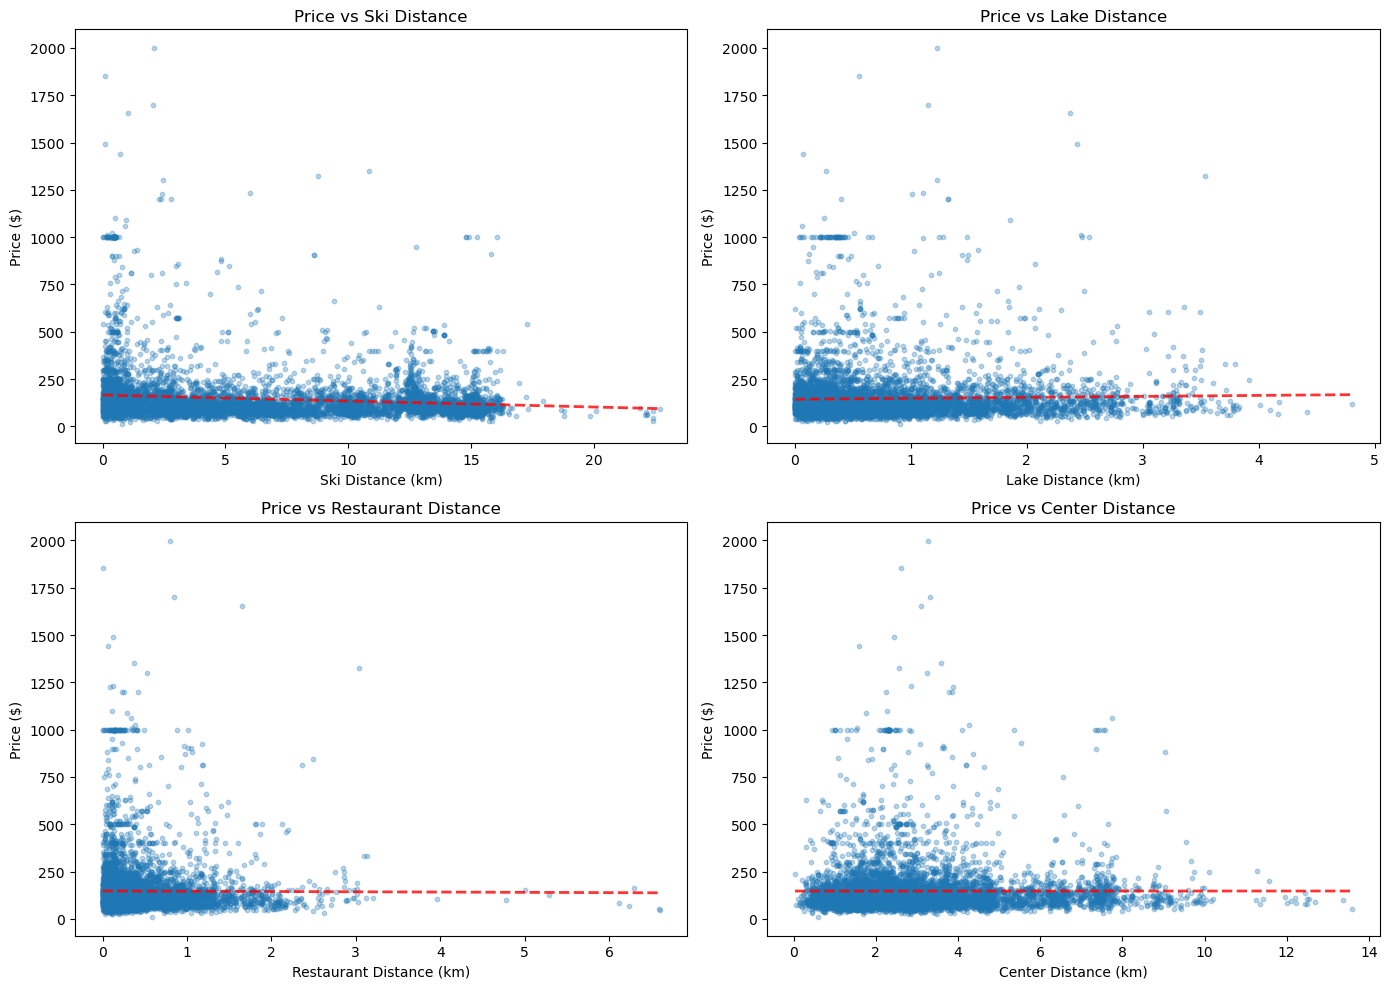

In [46]:
# Scatter plots for key distances
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_distances):
    x = df_clean[col] / 1000  # km
    y = df_clean['price']
    
    axes[i].scatter(x, y, alpha=0.3, s=10)
    axes[i].set_xlabel(f'{col.replace("dist_", "").replace("_", " ").title()} Distance (km)')
    axes[i].set_ylabel('Price ($)')
    axes[i].set_title(f'Price vs {col.replace("dist_", "").replace("_", " ").title()} Distance')
    
    # Add trend line
    z = np.polyfit(x.dropna(), y[x.notna()], 1)
    p = np.poly1d(z)
    axes[i].plot(x.dropna().sort_values(), p(x.dropna().sort_values()), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

PRICE PER PERSON ANALYSIS

=== STATISTICS ===
count    7660.000000
mean       36.785145
std        41.363024
min         2.285714
25%        20.972222
50%        28.000000
75%        39.250000
max       900.000000
Name: price_per_person, dtype: float64

Median: $28.00/person/night
Range: $2.29 - $900.00

=== COMPARISON: TOTAL vs PER PERSON ===
        Total Price  Price per Person
Min           10.00              2.29
Median       116.00             28.00
Mean         146.75             36.79
Max         1999.00            900.00

=== PRICE PER PERSON BY ROOM TYPE ===
                  mean  median  count
room_type                            
Entire home/apt  32.88   26.86   6691
Hotel room       91.42   66.00     18
Private room     63.37   42.58    944
Shared room      43.29   38.00      7


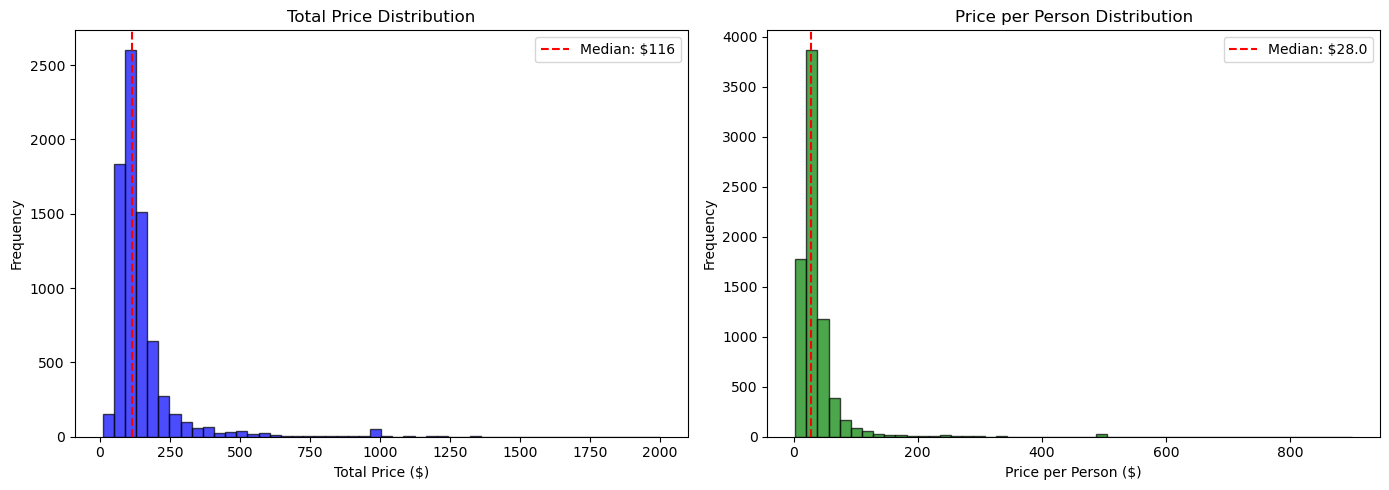


=== TOP 10 MOST EXPENSIVE PER PERSON ===
                       id   price  price_per_person  accommodates  \
2337             43194419   900.0             900.0             1   
2424             44142174  1010.0             505.0             2   
5824  1242877772298212083  1000.0             500.0             2   
5857  1252064998614191481  1000.0             500.0             2   
5858  1252084796597551436  1000.0             500.0             2   
5859  1252106761273661842  1000.0             500.0             2   
5861  1252137971215566032  1000.0             500.0             2   
5862  1252151131333451032  1000.0             500.0             2   
5863  1252163612850891697  1000.0             500.0             2   
5864  1252193232749968720  1000.0             500.0             2   

          municipality        room_type  
2337           Pinzolo     Private room  
2424  Dimaro Folgarida  Entire home/apt  
5824           Pinzolo     Private room  
5857         Tre Ville     Pri

In [47]:
# Calculate price per person
df['price_per_person'] = df['price'] / df['accommodates']

print("="*60)
print("PRICE PER PERSON ANALYSIS")
print("="*60)

print("\n=== STATISTICS ===")
print(df['price_per_person'].describe())
print(f"\nMedian: ${df['price_per_person'].median():.2f}/person/night")
print(f"Range: ${df['price_per_person'].min():.2f} - ${df['price_per_person'].max():.2f}")

# Compare with total price
print("\n=== COMPARISON: TOTAL vs PER PERSON ===")
comparison = pd.DataFrame({
    'Total Price': [df['price'].min(), df['price'].median(), df['price'].mean(), df['price'].max()],
    'Price per Person': [df['price_per_person'].min(), df['price_per_person'].median(), 
                         df['price_per_person'].mean(), df['price_per_person'].max()]
}, index=['Min', 'Median', 'Mean', 'Max'])
print(comparison.round(2))

# Price per person by room type
print("\n=== PRICE PER PERSON BY ROOM TYPE ===")
print(df.groupby('room_type')['price_per_person'].agg(['mean', 'median', 'count']).round(2))

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total price
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f'Median: ${df["price"].median():.0f}')
axes[0].set_xlabel('Total Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Total Price Distribution')
axes[0].legend()

# Price per person
axes[1].hist(df['price_per_person'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(df['price_per_person'].median(), color='red', linestyle='--', 
                label=f'Median: ${df["price_per_person"].median():.1f}')
axes[1].set_xlabel('Price per Person ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price per Person Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Top 10 most expensive per person
print("\n=== TOP 10 MOST EXPENSIVE PER PERSON ===")
expensive_pp = df.nlargest(10, 'price_per_person')[
    ['id', 'price', 'price_per_person', 'accommodates', 'municipality', 'room_type']
]
print(expensive_pp)

In [48]:
print("="*60)
print("SUMMARY FOR SPATIAL REGRESSION IN R")
print("="*60)

print(f"\n📊 Dataset: {len(df)} listings across {df['municipality'].nunique()} municipalities")
print(f"\n💰 Price Range: ${df['price'].min():.0f} - ${df['price'].max():.0f}")
print(f"   Median: ${df['price'].median():.0f}")

print(f"\n🏠 Room Types:")
for room_type, count in df['room_type'].value_counts().items():
    print(f"   - {room_type}: {count} ({count/len(df)*100:.1f}%)")

print(f"\n📍 Top 5 Municipalities:")
for muni, count in df['municipality'].value_counts().head(5).items():
    print(f"   - {muni}: {count} listings")

print(f"\n🔗 Variables for R:")
print(f"   - Dependent: log_price (log-transformed)")
print(f"   - Intrinsic: room_type, accommodates, n_reviews")
print(f"   - Spatial: {len(distance_cols)} distance variables")
print(f"   - Fixed effects: municipality (dummy variables)")
print(f"   - Coordinates: lat, long (for spatial weights matrix)")

print(f"\n✅ Dataset ready for spatial regression in R!")
print(f"   File: datasets/trentino_listings_maps.csv")

print("=== TOP 10 MOST EXPENSIVE LISTINGS ===")
expensive = df.nlargest(10, 'price')[['id', 'price', 'municipality', 'room_type', 'accommodates']]
print(expensive)

SUMMARY FOR SPATIAL REGRESSION IN R

📊 Dataset: 7660 listings across 158 municipalities

💰 Price Range: $10 - $1999
   Median: $116

🏠 Room Types:
   - Entire home/apt: 6691 (87.3%)
   - Private room: 944 (12.3%)
   - Hotel room: 18 (0.2%)
   - Shared room: 7 (0.1%)

📍 Top 5 Municipalities:
   - Riva del Garda: 745 listings
   - Trento: 468 listings
   - Arco: 434 listings
   - Pinzolo: 364 listings
   - Ledro: 334 listings

🔗 Variables for R:
   - Dependent: log_price (log-transformed)
   - Intrinsic: room_type, accommodates, n_reviews
   - Spatial: 12 distance variables
   - Fixed effects: municipality (dummy variables)
   - Coordinates: lat, long (for spatial weights matrix)

✅ Dataset ready for spatial regression in R!
   File: datasets/trentino_listings_maps.csv
=== TOP 10 MOST EXPENSIVE LISTINGS ===
                       id   price                   municipality  \
4623   980854821512800143  1999.0                Ville di Fiemme   
7658  1520323547190377970  1853.0              